# Movie Recommendation System Using TensorFlow

This notebook is heavily inspiration from the [TensorFlow recommender basics tutorial series](https://www.tensorflow.org/recommenders/examples/basic_retrieval).

Real-world recommender systems are often composed of two stages:
- Retrival Stage
- Ranking Stage

## Dataset

In this notebook, we are going to use the [MovieLens dataset by GroupLens](https://www.kaggle.com/datasets/grouplens/movielens-20m-dataset). For a comprehensive overview, you can refer to the dataset page on Kaggle.

# Imports

In [1]:
!pip install tensorflow==2.15.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.3/475.3 MB 3.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 60.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 92.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 4.2 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.17.2
    Uninstalling wrapt-1.17.2:
      Successfully uninstalled wrapt-1.17.2
  Attempting uninstall: keras
    Found existing installation: keras 3.8.0
    Uninstalling keras-3.8.0:
      Successfully uninstalled keras-3.8.0
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.18.0
    Uninstalling tensorboard-2.18.0:
      Successfully uninstalled tensorboard-2.18.0
  Attempting uninstall: ml-dtypes

In [2]:
!pip install -q tensorflow-recommenders
!pip install -q --upgrade tensorflow-datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.2/96.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.0/322.0 kB 6.1 MB/s eta 0:00:00a 0:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.8.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
tensorflow 2.15.1 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 6.32.0 which is incompatible.
google-api-core 1.34.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<4.0.0dev,>=3.19.5, but you have protobuf 6.32.0 which is incompatible.
google-cloud-translate 3.12.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have protobuf 6.32.0 which is incompatible.
dopamine-rl 4.1.2 requires 

In [3]:
import os
import pprint
import tempfile

from typing import Dict, Text

import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds

2025-09-09 03:45:54.424751: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-09-09 03:45:54.424829: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-09-09 03:45:54.426951: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [4]:
tf.__version__

'2.15.1'

In [5]:
import tensorflow_recommenders as tfrs

# EDA And Preprocessing

In [6]:
# Ratings data.
ratings = tfds.load("movielens/100k-ratings", split="train")
# Features of all the available movies.
movies = tfds.load("movielens/100k-movies", split="train")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/movielens/100k-movies/incomplete.8DQMC1_0.1.1/movielens-train.tfrecord*...…

Dataset movielens downloaded and prepared to /root/tensorflow_datasets/movielens/100k-movies/0.1.1. Subsequent calls will reuse this data.


Check the values

In [7]:
for x in ratings.take(1).as_numpy_iterator():
  pprint.pprint(x)

{'bucketized_user_age': 45.0,
 'movie_genres': array([7]),
 'movie_id': b'357',
 'movie_title': b"One Flew Over the Cuckoo's Nest (1975)",
 'raw_user_age': 46.0,
 'timestamp': 879024327,
 'user_gender': True,
 'user_id': b'138',
 'user_occupation_label': 4,
 'user_occupation_text': b'doctor',
 'user_rating': 4.0,
 'user_zip_code': b'53211'}


In [8]:
for x in movies.take(1).as_numpy_iterator():
  pprint.pprint(x)

{'movie_genres': array([4]),
 'movie_id': b'1681',
 'movie_title': b'You So Crazy (1994)'}


## Feature Selection
We are only intersted in the user preference

In [9]:
# ratings = ratings.map(lambda x: {
#     "movie_title": x["movie_title"],
#     "user_id": x["user_id"],
# })
ratings = ratings.map(lambda x: {
    "movie_title": x["movie_title"],
    "user_id": x["user_id"],
    "raw_user_age": x["raw_user_age"],
    "user_rating": x["user_rating"]
})
movies = movies.map(lambda x: x["movie_title"])

Print data after feature selection

In [10]:
for x in ratings.take(1).as_numpy_iterator():
  pprint.pprint(x)

{'movie_title': b"One Flew Over the Cuckoo's Nest (1975)",
 'raw_user_age': 46.0,
 'user_id': b'138',
 'user_rating': 4.0}


In [11]:
for x in movies.take(1).as_numpy_iterator():
  pprint.pprint(x)

b'You So Crazy (1994)'


## Train & Test Split

In [12]:
tf.random.set_seed(42)
train = ratings.shuffle(100_000, seed=42, reshuffle_each_iteration=False)

## Number of unique users and movies

In [13]:
movie_titles = movies.batch(1_000)
user_ids = ratings.batch(1_000_000).map(lambda x: x["user_id"])

unique_movie_titles = np.unique(np.concatenate(list(movie_titles)))
unique_user_ids = np.unique(np.concatenate(list(user_ids)))

unique_movie_titles[:10]

array([b"'Til There Was You (1997)", b'1-900 (1994)',
       b'101 Dalmatians (1996)', b'12 Angry Men (1957)', b'187 (1997)',
       b'2 Days in the Valley (1996)',
       b'20,000 Leagues Under the Sea (1954)',
       b'2001: A Space Odyssey (1968)',
       b'3 Ninjas: High Noon At Mega Mountain (1998)',
       b'39 Steps, The (1935)'], dtype=object)

In [14]:
len(unique_user_ids)

943

# Two-tower Retrieval Model

Retrieval models are often composed of two sub-models:

1. A query model computing the query representation (normally a fixed-dimensionality embedding vector) using query features.
2. A candidate model computing the candidate representation (an equally-sized vector) using the candidate features

The outputs of the two models are then multiplied together to give a query-candidate affinity score, with higher scores expressing a better match between the candidate and the query.

In [15]:
embedding_dimension = 32

## Query Sub-Model

In [16]:
user_model = tf.keras.Sequential([
  tf.keras.layers.StringLookup(
      vocabulary=unique_user_ids, mask_token=None),
  # We add an additional embedding to account for unknown tokens.
  tf.keras.layers.Embedding(len(unique_user_ids) + 1, embedding_dimension)
])

## Candidate Sub-Model

In [17]:
movie_model = tf.keras.Sequential([
  tf.keras.layers.StringLookup(
      vocabulary=unique_movie_titles, mask_token=None),
  tf.keras.layers.Embedding(len(unique_movie_titles) + 1, embedding_dimension)
])

## Metrics

In [18]:
# Preformance
metrics = tfrs.metrics.FactorizedTopK(
  candidates=movies.batch(128).map(movie_model)
)

In [19]:
# Loss
task = tfrs.tasks.Retrieval(
  metrics=metrics
)

## Architecture

In [20]:
class MovielensModel(tfrs.Model):
  def __init__(self, user_model, movie_model):
    super().__init__()
    self.movie_model: tf.keras.Model = movie_model
    self.user_model: tf.keras.Model = user_model
    self.task: tf.keras.layers.Layer = task

  def compute_loss(self, features: Dict[Text, tf.Tensor], training=False) -> tf.Tensor:
    # We pick out the user features and pass them into the user model.
    user_embeddings = self.user_model(features["user_id"])
    # And pick out the movie features and pass them into the movie model,
    # getting embeddings back.
    positive_movie_embeddings = self.movie_model(features["movie_title"])

    # The task computes the loss and the metrics.
    return self.task(user_embeddings, positive_movie_embeddings)

In [21]:
# # Create a retrieval model.
# model = MovieLensModel(user_model, movie_model, task)
# model.compile(optimizer=tf.keras.optimizers.Adagrad(0.5))

# # Train for 3 epochs.
# model.fit(ratings.batch(4096), epochs=3)

# # Use brute-force search to set up retrieval using the trained representations.
# index = tfrs.layers.factorized_top_k.BruteForce(model.user_model)
# index.index_from_dataset(
#     movies.batch(100).map(lambda title: (title, model.movie_model(title))))

# # Get some recommendations.
# _, titles = index(np.array(["42"]))
# print(f"Top 3 recommendations for user 42: {titles[0, :3]}")

In [22]:
retrival_model = MovielensModel(user_model, movie_model)
retrival_model.compile(optimizer=tf.keras.optimizers.Adagrad(learning_rate=0.1))

In [23]:
cached_train = train.shuffle(100_000).batch(8192).cache()

In [24]:
retrival_model.fit(cached_train, epochs=3)

Epoch 1/3
13/13 [==============================] - 26s 2s/step - factorized_top_k/top_1_categorical_accuracy: 0.0015 - factorized_top_k/top_5_categorical_accuracy: 0.0114 - factorized_top_k/top_10_categorical_accuracy: 0.0246 - factorized_top_k/top_50_categorical_accuracy: 0.1162 - factorized_top_k/top_100_categorical_accuracy: 0.2030 - loss: 64316.6508 - regularization_loss: 0.0000e+00 - total_loss: 64316.6508
Epoch 2/3
13/13 [==============================] - 17s 1s/step - factorized_top_k/top_1_categorical_accuracy: 0.0029 - factorized_top_k/top_5_categorical_accuracy: 0.0186 - factorized_top_k/top_10_categorical_accuracy: 0.0373 - factorized_top_k/top_50_categorical_accuracy: 0.1650 - factorized_top_k/top_100_categorical_accuracy: 0.2853 - loss: 62119.9914 - regularization_loss: 0.0000e+00 - total_loss: 62119.9914
Epoch 3/3
13/13 [==============================] - 17s 1s/step - factorized_top_k/top_1_categorical_accuracy: 0.0034 - factorized_top_k/top_5_categorical_accuracy: 0.0208

In [25]:
retrival_model.evaluate(cached_train, return_dict=True)

13/13 [==============================] - 16s 1s/step - factorized_top_k/top_1_categorical_accuracy: 0.0046 - factorized_top_k/top_5_categorical_accuracy: 0.0285 - factorized_top_k/top_10_categorical_accuracy: 0.0553 - factorized_top_k/top_50_categorical_accuracy: 0.2085 - factorized_top_k/top_100_categorical_accuracy: 0.3383 - loss: 60571.3682 - regularization_loss: 0.0000e+00 - total_loss: 60571.3682


{'factorized_top_k/top_1_categorical_accuracy': 0.004639999940991402,
 'factorized_top_k/top_5_categorical_accuracy': 0.02848000079393387,
 'factorized_top_k/top_10_categorical_accuracy': 0.05525000020861626,
 'factorized_top_k/top_50_categorical_accuracy': 0.20845000445842743,
 'factorized_top_k/top_100_categorical_accuracy': 0.3382999897003174,
 'loss': 11411.4013671875,
 'regularization_loss': 0,
 'total_loss': 11411.4013671875}

## Inference

In [26]:
# Create a model that takes in raw query features, and
index = tfrs.layers.factorized_top_k.BruteForce(retrival_model.user_model)
# recommends movies out of the entire movies dataset.
index.index_from_dataset(
  tf.data.Dataset.zip((movies.batch(100), movies.batch(100).map(retrival_model.movie_model)))
)

# Get recommendations, user 42
_, titles = index(tf.constant(["42"]))
print(f"Recommendations for user 42: {titles[0, :3]}")

Recommendations for user 42: [b'Angels in the Outfield (1994)' b'Rudy (1993)'
 b'Father of the Bride Part II (1995)']


In [27]:
titles

<tf.Tensor: shape=(1, 10), dtype=string, numpy=
array([[b'Angels in the Outfield (1994)', b'Rudy (1993)',
        b'Father of the Bride Part II (1995)',
        b'Indian in the Cupboard, The (1995)', b'Rent-a-Kid (1995)',
        b'Forget Paris (1995)', b'Man Without a Face, The (1993)',
        b"Kid in King Arthur's Court, A (1995)", b'Jack (1996)',
        b'Grease (1978)']], dtype=object)>

In [28]:
tf.strings.length(titles)

<tf.Tensor: shape=(1, 10), dtype=int32, numpy=array([[29, 11, 34, 34, 17, 19, 30, 36, 11, 13]], dtype=int32)>

In [29]:
# Get recommendations, user 2
_, titles = index(tf.constant(["2"]))
print(f"Recommendations for user 2: {titles[0, :3]}")

Recommendations for user 2: [b'A Chef in Love (1996)' b'Kolya (1996)' b'Brassed Off (1996)']


In [30]:
titles

<tf.Tensor: shape=(1, 10), dtype=string, numpy=
array([[b'A Chef in Love (1996)', b'Kolya (1996)', b'Brassed Off (1996)',
        b"Ulee's Gold (1997)", b"Ulee's Gold (1997)",
        b'Postino, Il (1994)', b'Wings of the Dove, The (1997)',
        b'Secrets & Lies (1996)', b'Promesse, La (1996)',
        b'Sense and Sensibility (1995)']], dtype=object)>

In [31]:
tf.strings.length(titles)

<tf.Tensor: shape=(1, 10), dtype=int32, numpy=array([[21, 12, 18, 18, 18, 18, 29, 21, 19, 28]], dtype=int32)>

In [32]:
# Get recommendations, user 2
_, titles = index(tf.constant(["200"]))
print(f"Recommendations for user 200: {titles[0, :3]}")

Recommendations for user 200: [b'First Kid (1996)' b'Quest, The (1996)'
 b"Robert A. Heinlein's The Puppet Masters (1994)"]


In [33]:
titles

<tf.Tensor: shape=(1, 10), dtype=string, numpy=
array([[b'First Kid (1996)', b'Quest, The (1996)',
        b"Robert A. Heinlein's The Puppet Masters (1994)",
        b'Little Rascals, The (1994)', b'Flipper (1996)',
        b'Homeward Bound II: Lost in San Francisco (1996)',
        b'Phantom, The (1996)', b'Goofy Movie, A (1995)',
        b'Casper (1995)', b"Pete's Dragon (1977)"]], dtype=object)>

# Ranking Model

## Data Preparation

In [34]:
ratings = tfds.load("movielens/100k-ratings", split="train")

ratings = ratings.map(lambda x: {
    "movie_title": x["movie_title"],
    "user_id": x["user_id"],
    "raw_user_age": x["raw_user_age"],
    "user_rating": x["user_rating"]
})

In [35]:
user_ids = set()

for item in ratings:
    user_ids.add(item['user_id'].numpy())  # Convert tensor to Python value

print(f"Number of unique users: {len(user_ids)}")


Number of unique users: 943


In [36]:
# expected_user_ids = set(range(1, 944))  # from 1 to 943 (inclusive)
# actual_user_ids = set()

# for item in ratings:
#     user_id = item["user_id"].numpy()  # Convert tf.Tensor to int
#     actual_user_ids.add(user_id)

# # Check if the sets match
# if actual_user_ids == expected_user_ids:
#     print("✅ User IDs are sequential from 1 to 943 with no gaps.")
# else:
#     print("❌ User IDs are not sequential from 1 to 943.")
#     print(f"Missing IDs: {sorted(expected_user_ids - actual_user_ids)}")
#     print(f"Extra IDs: {sorted(actual_user_ids - expected_user_ids)}")


In [37]:
tf.random.set_seed(42)
shuffled = ratings.shuffle(100_000, seed=42, reshuffle_each_iteration=False)

train = shuffled.take(80_000)
test = shuffled.skip(80_000).take(20_000)

In [38]:
for example in train.take(1):
    print("Keys available in example:", example.keys())


Keys available in example: dict_keys(['movie_title', 'user_id', 'raw_user_age', 'user_rating'])


In [39]:
target_user = "17"

for item in test:
    user_id = item['user_id'].numpy().decode('utf-8')
    if user_id == target_user:
        result = {
            'movie_title': item['movie_title'].numpy().decode('utf-8'),
            'user_id': user_id,
            'user_rating': float(item['user_rating'].numpy()) if 'user_rating' in item else None
        }
        print(result)


{'movie_title': 'Phenomenon (1996)', 'user_id': '17', 'user_rating': 1.0}
{'movie_title': "Devil's Own, The (1997)", 'user_id': '17', 'user_rating': 2.0}
{'movie_title': 'Fargo (1996)', 'user_id': '17', 'user_rating': 4.0}
{'movie_title': 'Twelve Monkeys (1995)', 'user_id': '17', 'user_rating': 4.0}
{'movie_title': 'Trainspotting (1996)', 'user_id': '17', 'user_rating': 4.0}
{'movie_title': 'Breaking the Waves (1996)', 'user_id': '17', 'user_rating': 2.0}


In [40]:
# import pandas as pd

# data = {
#     'movie_title': [],
#     'user_id': [],
#     'user_rating': [],
#     'raw_user_age':[]
# }

# for example in dataset:
#     data['movie_title'].append(example['movie_title'].numpy().decode('utf-8'))
#     data['user_id'].append(example['user_id'].numpy().decode('utf-8'))
#     data['user_rating'].append(float(example['user_rating'].numpy()))

# df = pd.DataFrame(data)
# df.to_csv('output.csv', index=False)

In [41]:
movie_titles = ratings.batch(1_000_000).map(lambda x: x["movie_title"])
user_ids = ratings.batch(1_000_000).map(lambda x: x["user_id"])

unique_movie_titles = np.unique(np.concatenate(list(movie_titles)))
unique_user_ids = np.unique(np.concatenate(list(user_ids)))

## Architecture

In [42]:
class RankingModel(tf.keras.Model):

  def __init__(self):
    super().__init__()
    embedding_dimension = 32

    # Compute embeddings for users.
    self.user_embeddings = tf.keras.Sequential([
      tf.keras.layers.StringLookup(
        vocabulary=unique_user_ids, mask_token=None),
      tf.keras.layers.Embedding(len(unique_user_ids) + 1, embedding_dimension)
    ])

    # Compute embeddings for movies.
    self.movie_embeddings = tf.keras.Sequential([
      tf.keras.layers.StringLookup(
        vocabulary=unique_movie_titles, mask_token=None),
      tf.keras.layers.Embedding(len(unique_movie_titles) + 1, embedding_dimension)
    ])

    # Compute predictions.
    self.ratings = tf.keras.Sequential([
      # Learn multiple dense layers.
      tf.keras.layers.Dense(256, activation="relu"),
      tf.keras.layers.Dense(64, activation="relu"),
      # Make rating predictions in the final layer.
      tf.keras.layers.Dense(1)
    ])

  def call(self, inputs):

    user_id, movie_title = inputs

    user_embedding = self.user_embeddings(user_id)
    movie_embedding = self.movie_embeddings(movie_title)

    return self.ratings(tf.concat([user_embedding, movie_embedding], axis=1))

In [43]:
# This model takes user ids and movie titles, and outputs a predicted rating
RankingModel()((["42"], ["One Flew Over the Cuckoo's Nest (1975)"]))

<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[0.0277464]], dtype=float32)>

## Loss and metrics

In [44]:
rating_task = tfrs.tasks.Ranking(
  loss = tf.keras.losses.MeanSquaredError(),
  metrics=[tf.keras.metrics.RootMeanSquaredError()]
)

## Full Model Implementation

In [45]:
class MovielensModel(tfrs.models.Model):

  def __init__(self):
    super().__init__()
    self.ranking_model: tf.keras.Model = RankingModel()
    self.task: tf.keras.layers.Layer = rating_task

  def call(self, features: Dict[str, tf.Tensor]) -> tf.Tensor:
    return self.ranking_model(
        (features["user_id"], features["movie_title"]))

  def compute_loss(self, features: Dict[Text, tf.Tensor], training=False) -> tf.Tensor:
    labels = features.pop("user_rating")

    rating_predictions = self(features)

    # The task computes the loss and the metrics.
    return self.task(labels=labels, predictions=rating_predictions)

In [46]:
ranking_model = MovielensModel()
ranking_model.compile(optimizer=tf.keras.optimizers.Adagrad(learning_rate=0.1))

In [47]:
cached_train = train.shuffle(100_000).batch(8192).cache()
cached_test = test.batch(4096).cache()

In [48]:
ranking_model.fit(cached_train, epochs=3)

Epoch 1/3
10/10 [==============================] - 3s 35ms/step - root_mean_squared_error: 2.2027 - loss: 4.4560 - regularization_loss: 0.0000e+00 - total_loss: 4.4560
Epoch 2/3
10/10 [==============================] - 0s 18ms/step - root_mean_squared_error: 1.1209 - loss: 1.2585 - regularization_loss: 0.0000e+00 - total_loss: 1.2585
Epoch 3/3
10/10 [==============================] - 0s 19ms/step - root_mean_squared_error: 1.1121 - loss: 1.2388 - regularization_loss: 0.0000e+00 - total_loss: 1.2388


In [49]:
ranking_model.evaluate(cached_test, return_dict=True)

5/5 [==============================] - 2s 17ms/step - root_mean_squared_error: 1.1065 - loss: 1.2192 - regularization_loss: 0.0000e+00 - total_loss: 1.2192


{'root_mean_squared_error': 1.106452465057373,
 'loss': 1.1972037553787231,
 'regularization_loss': 0,
 'total_loss': 1.1972037553787231}

## Inference

In [50]:
test_ratings = {}
test_movie_titles = ["M*A*S*H (1970)", "Dances with Wolves (1990)", "Speed (1994)"]
for movie_title in test_movie_titles:
  test_ratings[movie_title] = ranking_model({
      "user_id": np.array(["42"]),
      "movie_title": np.array([movie_title])
  })

print("Ratings:")
for title, score in sorted(test_ratings.items(), key=lambda x: x[1], reverse=True):
  print(f"{title}: {score}")

Ratings:
M*A*S*H (1970): [[3.5954869]]
Dances with Wolves (1990): [[3.5762491]]
Speed (1994): [[3.4901795]]


# Full Recommder System

Combine the retrival model with the ranking model to provide accurate recommendations.

In [51]:
class Recommender():
    def __init__(self, retrival_model, ranking_model):
        index = tfrs.layers.factorized_top_k.BruteForce(retrival_model.user_model)
        index.index_from_dataset(
          tf.data.Dataset.zip((movies.batch(100), movies.batch(100).map(retrival_model.movie_model)))
        )
        self.retrival_model = index
        self.ranking_model = ranking_model
    
    def predict(self, user_id):
        _, titles = self.retrival_model(tf.constant([user_id]))
        ratings = []
        for index, title in enumerate(titles[0]):
            ratings.append(self.ranking_model({
                "user_id": np.array([user_id]),
                "movie_title": np.array([title.numpy().decode('utf-8')])
            }))
        return sorted(zip(titles.numpy().tolist()[0], tf.squeeze(tf.concat(ratings, axis=0)).numpy().tolist()), key=lambda x: x[1], reverse=True)

In [52]:
recommender_model = Recommender(retrival_model, ranking_model)

In [53]:
recommender_model.predict("50")

[(b'Bound (1996)', 3.7428126335144043),
 (b'Breaking the Waves (1996)', 3.6262593269348145),
 (b"Young Poisoner's Handbook, The (1995)", 3.624370813369751),
 (b'Pillow Book, The (1995)', 3.598506450653076),
 (b'Hard Eight (1996)', 3.5902204513549805),
 (b'Chungking Express (1994)', 3.5554981231689453),
 (b'Crash (1996)', 3.538353204727173),
 (b'A Chef in Love (1996)', 3.5337955951690674),
 (b'Cement Garden, The (1993)', 3.5298314094543457),
 (b'I Shot Andy Warhol (1996)', 3.5261123180389404)]

# **Visualization of ratings in train set, test set and prediction**

In [54]:
train

<_TakeDataset element_spec={'movie_title': TensorSpec(shape=(), dtype=tf.string, name=None), 'user_id': TensorSpec(shape=(), dtype=tf.string, name=None), 'raw_user_age': TensorSpec(shape=(), dtype=tf.float32, name=None), 'user_rating': TensorSpec(shape=(), dtype=tf.float32, name=None)}>

Determine the number of unique users

In [55]:
import tensorflow_datasets as tfds
import tensorflow as tf
import collections

# Create a set to store unique user IDs
user_ids = set()

for example in test:
    user_ids.add(example["user_id"].numpy())

print(f"Number of unique users in train: {len(user_ids)}")


Number of unique users in train: 942


In [56]:
user_ids = set()

for item in ratings:
    user_ids.add(item['user_id'].numpy())  # Convert tensor to Python value

print(f"Number of unique users: {len(user_ids)}")


Number of unique users: 943


In [57]:
from collections import defaultdict

user_ratings = defaultdict(list)

for example in train:
    user_id = example["user_id"].numpy().decode("utf-8")
    rating = example["user_rating"].numpy()
    user_ratings[user_id].append(rating)


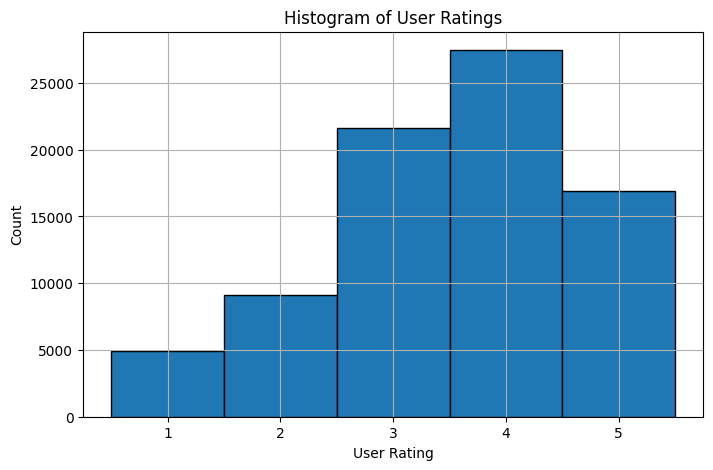

In [58]:
import matplotlib.pyplot as plt

# Flatten all ratings into a single list
all_ratings = [rating for ratings in user_ratings.values() for rating in ratings]

plt.figure(figsize=(8, 5))
plt.hist(all_ratings, bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5], edgecolor='black', align='mid')
plt.xlabel("User Rating")
plt.ylabel("Count")
plt.title("Histogram of User Ratings")
plt.xticks([1, 2, 3, 4, 5])
plt.grid(True)
plt.show()


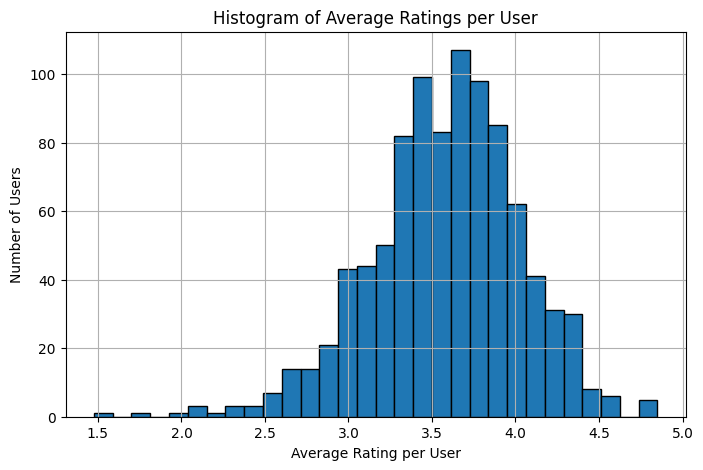

In [59]:
average_ratings = [sum(r)/len(r) for r in user_ratings.values()]

plt.figure(figsize=(8, 5))
plt.hist(average_ratings, bins=30, edgecolor='black')
plt.xlabel("Average Rating per User")
plt.ylabel("Number of Users")
plt.title("Histogram of Average Ratings per User")
plt.grid(True)
plt.show()


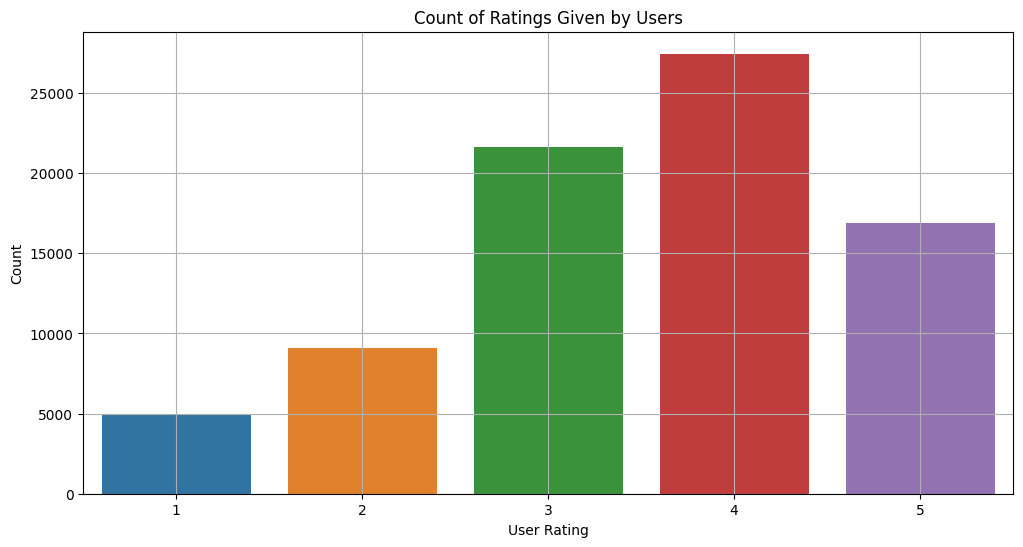

In [60]:
import seaborn as sns
import pandas as pd

# Flatten all (user_id, rating) pairs
all_data = []
for user_id, ratings in user_ratings.items():
    for r in ratings:
        all_data.append((user_id, r))

df = pd.DataFrame(all_data, columns=["user_id", "user_rating"])

# Optional: convert ratings to integers if needed
df["user_rating"] = df["user_rating"].astype(int)

# Plot user_id vs rating count (warning: many users -> sparse plot)
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x="user_rating")
plt.title("Count of Ratings Given by Users")
plt.xlabel("User Rating")
plt.ylabel("Count")
plt.grid(True)
plt.show()


In [61]:
unique_users = set()
for example in train.as_numpy_iterator():
    unique_users.add(example["user_id"].decode("utf-8"))

print("Unique users in train:", len(unique_users))


Unique users in train: 943


# Visualization for prediction ratings

In [62]:
print(type(ratings))             # List? Dataset? Tensor?
print(len(ratings))              # How many elements?
print(type(ratings[0]))          # What's the first element?
print(ratings[0])                # What's inside?


<class 'list'>
13
<class 'numpy.float32'>
3.0


In [63]:
import tensorflow_datasets as tfds

ratings = tfds.load("movielens/100k-ratings", split="train")

# Map to keep only the fields you want
ratings = ratings.map(lambda x: {
    "movie_title": x["movie_title"],
    "user_id": x["user_id"],
    "raw_user_age": x["raw_user_age"],
    "user_rating": x["user_rating"]
})


In [64]:
unique_users = set()
for ex in ratings.as_numpy_iterator():
    user_id = ex["user_id"].decode("utf-8")
    unique_users.add(user_id)

print(f"Found {len(unique_users)} unique users.")


Found 943 unique users.


In [65]:
import numpy as np
from tqdm import tqdm  # progress bar
import matplotlib.pyplot as plt

recommender_model = Recommender(retrival_model, ranking_model)

user_avg_ratings = {}

for user_id in tqdm(user_ids):
    try:
        # Get predictions (sorted by predicted rating desc)
        predictions = recommender_model.predict(user_id)
        
        # Take top 10 predicted ratings (change as needed)
        top_ratings = [r for _, r in predictions[:10]]
        
        # Compute average rating for this user
        avg_rating = np.mean(top_ratings)
        
        user_avg_ratings[user_id] = avg_rating
    except Exception as e:
        print(f"Error for user {user_id}: {e}")


100%|██████████| 943/943 [00:49<00:00, 19.01it/s]


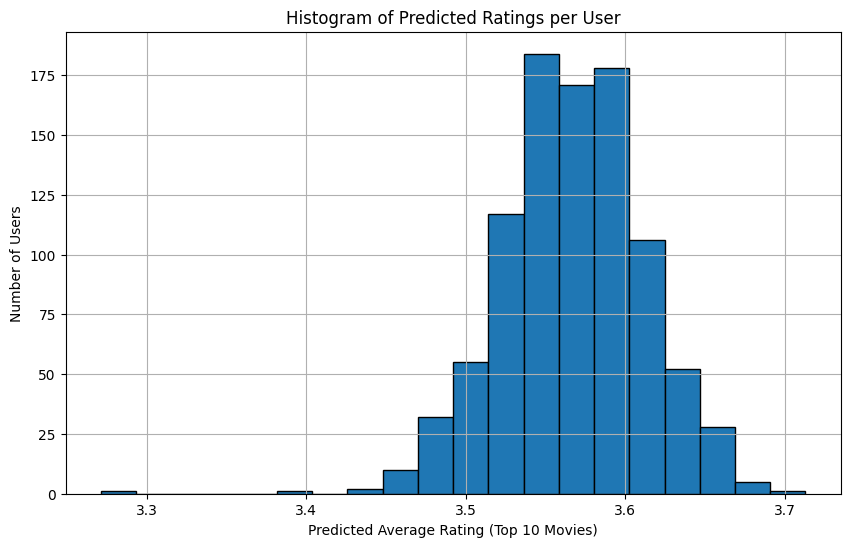

In [66]:
ratings_list = list(user_avg_ratings.values())

plt.figure(figsize=(10, 6))
plt.hist(ratings_list, bins=20, edgecolor='black')
plt.xlabel("Predicted Average Rating (Top 10 Movies)")
plt.ylabel("Number of Users")
plt.title("Histogram of Predicted Ratings per User")
plt.grid(True)
plt.show()


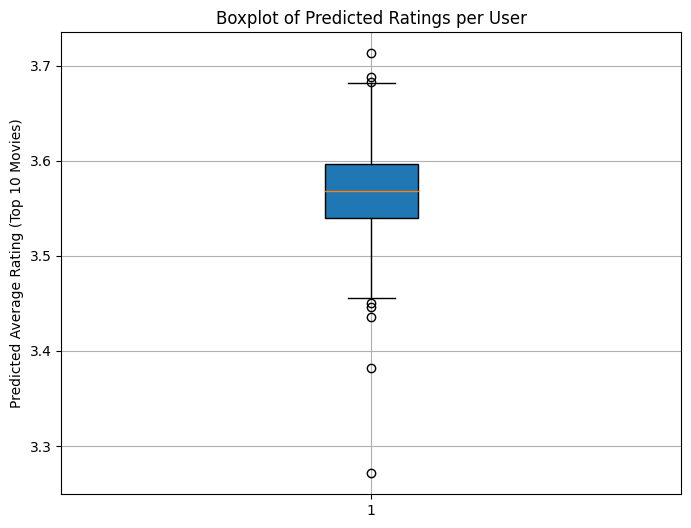

In [67]:
import matplotlib.pyplot as plt

ratings_list = list(user_avg_ratings.values())

plt.figure(figsize=(8, 6))
plt.boxplot(ratings_list, vert=True, patch_artist=True)
plt.ylabel("Predicted Average Rating (Top 10 Movies)")
plt.title("Boxplot of Predicted Ratings per User")
plt.grid(True)
plt.show()


100%|██████████| 943/943 [00:51<00:00, 18.39it/s]


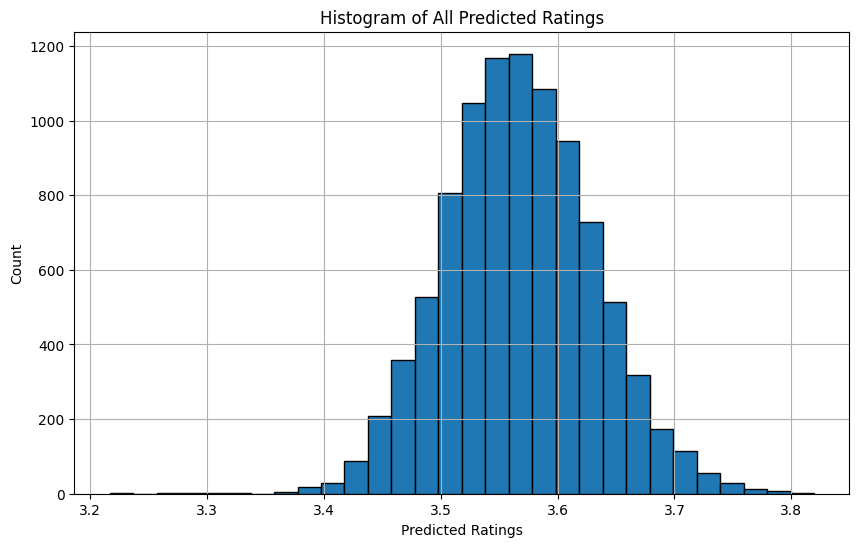

In [68]:
all_predicted_ratings = []

for user_id in tqdm(user_ids):
    try:
        predictions = recommender_model.predict(user_id)
        # predictions is list of (movie_title, rating)
        ratings_only = [r for _, r in predictions]  # all predicted ratings for that user
        all_predicted_ratings.extend(ratings_only)
    except Exception as e:
        print(f"Error for user {user_id}: {e}")


import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(all_predicted_ratings, bins=30, edgecolor='black')
plt.xlabel("Predicted Ratings")
plt.ylabel("Count")
plt.title("Histogram of All Predicted Ratings")
plt.grid(True)
plt.show()


# ***Visualization for test ratings***

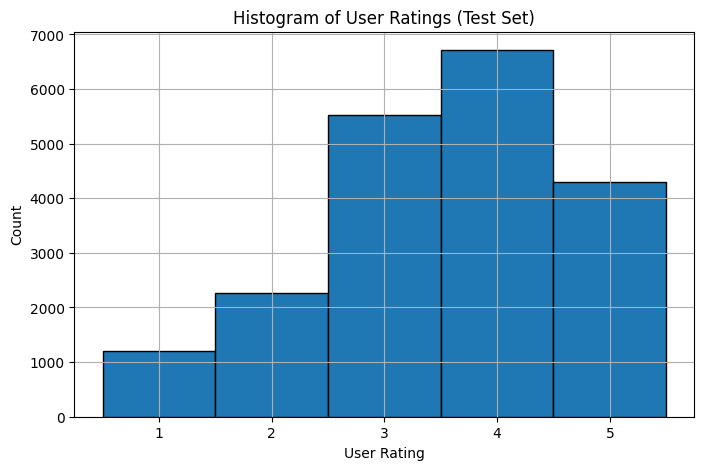

In [69]:
from collections import defaultdict
import matplotlib.pyplot as plt

# Aggregate ratings by user_id in test dataset
user_ratings_test = defaultdict(list)

for example in test:
    user_id = example["user_id"].numpy()
    # Decode if bytes, else use directly
    if isinstance(user_id, bytes):
        user_id = user_id.decode("utf-8")
    rating = example["user_rating"].numpy()
    user_ratings_test[user_id].append(rating)

# Flatten all ratings into a single list
all_ratings_test = [rating for ratings in user_ratings_test.values() for rating in ratings]

plt.figure(figsize=(8, 5))
plt.hist(all_ratings_test, bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5], edgecolor='black', align='mid')
plt.xlabel("User Rating")
plt.ylabel("Count")
plt.title("Histogram of User Ratings (Test Set)")
plt.xticks([1, 2, 3, 4, 5])
plt.grid(True)
plt.show()


In [70]:
import pandas as pd

def dataset_to_df(dataset):
    data = {"movie_title": [], "user_id": [], "raw_user_age": [], "user_rating": []}
    
    for example in dataset:
        for key in data.keys():
            value = example[key].numpy()
            if isinstance(value, bytes):
                value = value.decode('utf-8')
            data[key].append(value)
    return pd.DataFrame(data)

# Extract train and test DataFrames
train_df = dataset_to_df(train)
test_df = dataset_to_df(test)

# Save to CSV
train_df.to_csv("train_dataset.csv", index=False)
test_df.to_csv("test_dataset.csv", index=False)


# ***Rescaling the prediction between 1 to 5***

100%|██████████| 943/943 [00:48<00:00, 19.63it/s]


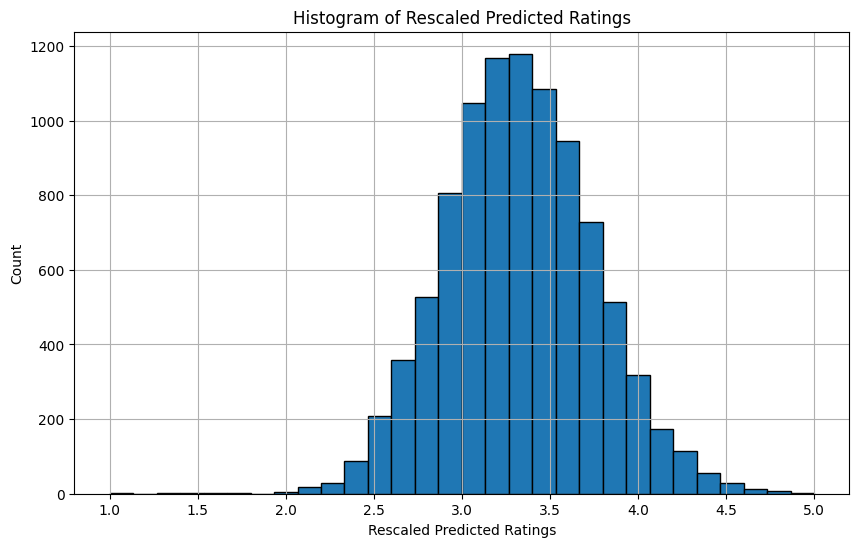

In [71]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

all_predicted_ratings = []

# Collect all predicted ratings
for user_id in tqdm(user_ids):
    try:
        predictions = recommender_model.predict(user_id)
        ratings_only = [r for _, r in predictions]
        all_predicted_ratings.extend(ratings_only)
    except Exception as e:
        print(f"Error for user {user_id}: {e}")

# Convert to numpy array
all_predicted_ratings = np.array(all_predicted_ratings).reshape(-1, 1)

# Rescale to range [1, 5]
scaler = MinMaxScaler(feature_range=(1, 5))
scaled_ratings = scaler.fit_transform(all_predicted_ratings).flatten()

# Plot the scaled ratings
plt.figure(figsize=(10, 6))
plt.hist(scaled_ratings, bins=30, edgecolor='black')
plt.xlabel("Rescaled Predicted Ratings")
plt.ylabel("Count")
plt.title("Histogram of Rescaled Predicted Ratings")
plt.grid(True)
plt.show()


# ***Rescaled pred***

In [74]:
scaler.fit(all_predicted_ratings_np)  # <-- fitted on global predictions

MinMaxScaler(feature_range=(1, 5))

In [78]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Step 1: Get predictions for user 50
predictions = recommender_model.predict("12")  # List of (movie_title, rating)

# Step 2: Extract ratings
ratings_only = np.array([r for _, r in predictions]).reshape(-1, 1)

# Step 3: Apply previously fitted scaler
rescaled_ratings = scaler.transform(ratings_only).flatten()

# Step 4: Combine titles with rescaled ratings
rescaled_predictions = [(title, rating) for (title, _), rating in zip(predictions, rescaled_ratings)]

# Optional: print top 10
for title, rating in rescaled_predictions[:10]:
    print(f"{title}: {rating:.2f}")


b'E.T. the Extra-Terrestrial (1982)': 3.86
b'Back to the Future (1985)': 3.78
b'Dead Poets Society (1989)': 3.73
b'Forrest Gump (1994)': 3.63
b'When Harry Met Sally... (1989)': 3.63
b'Sound of Music, The (1965)': 3.51
b'Dances with Wolves (1990)': 3.51
b'Indiana Jones and the Last Crusade (1989)': 3.48
b"Schindler's List (1993)": 3.20
b'Field of Dreams (1989)': 3.17


In [79]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Step 1: Get predictions for user 50
predictions = recommender_model.predict("50")  # List of (movie_title, rating)

# Step 2: Extract ratings
ratings_only = np.array([r for _, r in predictions]).reshape(-1, 1)

# Step 3: Apply previously fitted scaler
rescaled_ratings = scaler.transform(ratings_only).flatten()

# Step 4: Combine titles with rescaled ratings
rescaled_predictions = [(title, rating) for (title, _), rating in zip(predictions, rescaled_ratings)]

# Optional: print top 10
for title, rating in rescaled_predictions[:10]:
    print(f"{title}: {rating:.2f}")


b'Bound (1996)': 4.49
b'Breaking the Waves (1996)': 3.72
b"Young Poisoner's Handbook, The (1995)": 3.71
b'Pillow Book, The (1995)': 3.53
b'Hard Eight (1996)': 3.48
b'Chungking Express (1994)': 3.25
b'Crash (1996)': 3.13
b'A Chef in Love (1996)': 3.10
b'Cement Garden, The (1993)': 3.08
b'I Shot Andy Warhol (1996)': 3.05
